# Meter, rhyme and sound of the Spanish sonnet

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SergeyShk/esTS/blob/master/examples/03_sonnets.ipynb)

The notebook follows the Spanish sonnet from the 15th century to the early 20th on the 4,259 sonnets of `SpanishSonnets`, the public-domain part of the [Diachronic Spanish Sonnet Corpus](https://github.com/pruizf/disco) (DISCO). `VerseStats` scans every sonnet - its meter, stresses, types of the endecasílabo and rhyme - and the scansion is checked against the automatic annotation of meter and rhyme that the corpus carries; `PhonStats` measures the sound of the poems. Every section links to the page of the [documentation](https://sergeyshk.github.io/esTS/) with all the statistics and parameters.

## Installation

The notebook needs esTS 0.6 or newer. In Colab the cell installs it; where it is installed it does nothing. The verse and phonetic statistics work on plain strings with the rules of esTS, so this notebook needs no spaCy model.

In [1]:
import importlib.metadata
import subprocess
import sys

try:
    installed = importlib.metadata.version("pyests")
except importlib.metadata.PackageNotFoundError:
    installed = "0"
if tuple(map(int, installed.split(".")[:2])) < (0, 6):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyests>=0.6"], check=True)

In [2]:
import re
from collections import Counter
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ests import PhonStats, VerseStats
from ests.constants import VERSE_METERS
from ests.datasets import SpanishSonnets
from ests.phon_stats import calc_alliteration, calc_assonance

## The corpus

[`SpanishSonnets`](https://sergeyshk.github.io/esTS/datasets/spanishsonnets/) gives every sonnet with its author, period and the country of birth of the author, and with the annotation of DISCO for every line: the metrical pattern (`+` a stressed syllable, `-` an unstressed one, so its length is the number of metrical syllables) and the label of the rhyme. The annotation is automatic - the scansion by ADSO and Jumper, the rhyme by RhymeTagger ([Ruiz Fabo et al., 2021](https://doi.org/10.1093/llc/fqaa035)) - so it is a reference to compare with, not a gold standard. For the comparison of Spain and America the poets born in the Spanish-speaking countries of America are grouped together.

In [3]:
ss = SpanishSonnets()
ss.download()
records = list(ss.get_records())

AMERICA = {
    "Argentina", "Bolivia", "Chile", "Colombia", "Costa Rica", "Cuba", "Ecuador", "Honduras",
    "México", "Nicaragua", "Panamá", "Paraguay", "Perú", "Puerto Rico", "República Dominicana",
    "Uruguay", "Venezuela",
}  # fmt: skip
sonnets = pd.DataFrame(
    {
        "period": record["period"],
        "author": record["author"],
        "country": record["country"] or "unknown",
        "n_lines": len(record["meter"]),
    }
    for record in records
)
sonnets["region"] = np.select(
    [sonnets.country == "España", sonnets.country.isin(AMERICA)], ["Spain", "America"], "other"
)
print(f"{len(sonnets)} sonnets by {sonnets.author.nunique()} authors")

4259 sonnets by 1167 authors


In [4]:
top_countries = (
    sonnets.country.value_counts(sort=False).sort_values(ascending=False, kind="stable").index[:8]
)
country = sonnets.country.where(sonnets.country.isin(top_countries), "other")
by_country = pd.crosstab(country, sonnets.period, margins=True, margins_name="all")
by_country.loc[[*top_countries, "other", "all"]]

period,15th-17th,18th,19th,20th,all
country,,,,,
España,1002,280,1106,0,2388
Cuba,5,20,694,0,719
Perú,0,0,204,0,204
México,8,3,180,0,191
Nicaragua,0,0,141,0,141
Colombia,0,2,98,0,100
Argentina,2,0,91,0,93
Uruguay,0,0,76,0,76
other,71,16,255,5,347


In [5]:
print(
    "Countries of the region other:", sorted(sonnets.country[sonnets.region == "other"].unique())
)
pd.crosstab(sonnets.region, sonnets.period, margins=True, margins_name="all")

Countries of the region other: ['Brasil', 'Filipinas', 'Italia', 'Portugal', 'unknown']


period,15th-17th,18th,19th,20th,all
region,,,,,
America,17,32,1709,0,1758
Spain,1002,280,1106,0,2388
other,69,9,30,5,113
all,1088,321,2845,5,4259


The corpus is uneven in time and place. The 19th century holds 2,845 of the 4,259 sonnets and is the only one with many American poets: 1,709 of its sonnets against 1,106 from Spain, 694 from Cuba alone. The 15th-17th and 18th centuries are Spanish almost wholly (1,002 of 1,088 and 280 of 321). The 20th century is five sonnets - by the Filipino poet Cecilio Apóstol, as the page of the dataset says - too few to stand for a period, so the comparisons by period below leave it out, while the checks against DISCO take all the sonnets. The 113 sonnets of the region "other" are by poets born in Portugal, the Philippines, Brazil or Italy or of unknown birth.

In [6]:
PERIODS = ["15th-17th", "18th", "19th"]
COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]

## Meter

[`VerseStats`](https://sergeyshk.github.io/esTS/stats/verse_stats/) splits the words into syllables, joins the vowels of neighbouring words (synalepha), counts every line up to its last stress and one syllable more, and fits all the lines to the most common length - the [algorithm](https://sergeyshk.github.io/esTS/stats/verse_stats_funcs/#algorithm) is described in the documentation. The first sonnet of Juan de Arguijo shows the scansion of esTS next to the pattern and the rhyme label of DISCO.

In [7]:
verses = [VerseStats(record["text"]) for record in records]
sonnets["meter"] = [verse.meter or "none" for verse in verses]

index = next(i for i, record in enumerate(records) if record["author"] == "Juan de Arguijo")
record, verse = records[index], verses[index]
print(record["author"], f"({record['birth']}-{record['death']}):", verse.meter, verse.form)
print(f"{'esTS':<12} {'DISCO':<12} rhyme")
labels = "".join(verse.rhyme_schemes)
for line, ours, theirs, label, disco_label in zip(
    verse.lines, verse.patterns, record["meter"], labels, record["rhyme"], strict=True
):
    print(f"{ours:<12} {theirs:<12} {label} {disco_label}  {line}")

Juan de Arguijo (1560-1623): endecasílabo soneto
esTS         DISCO        rhyme
-+---+-+-+-  -+---+-+-+-  A A  De ciega oscuridad y horror cubierta
-+-+-+---+-  -+-+-----+-  B B  está la tierra, en tanto que el hermano
---+-+-+-+-  ---+-+-+-+-  B B  de la silvestre diosa sale ufano
-+-+---+-+-  -+-+---+-+-  A A  del rojo Oriente por la ebúrnea puerta
---+-+-+-+-  ---+-+-+-+-  A A  Ante sus ojos ve la muerte cierta
--+--+---+-  --+--+---+-  B B  el piloto en el piélago inhumano
-+-+---+-+-  -+-+---+-+-  B B  mas dando el viento a sus deseos la mano
-+-+---+-+-  -+-+---+-+-  A A  en vida trueca la esperanza muerta
---+-+---+-  ---+-+---+-  C C  Tras la importuna guerra se consigue
---+-+-+-+-  ---+-+-+-+-  D D  para dichosos años paz segura
+--+---+-+-  +------+-+-  E E  Tú, pues en medio de tus males fía;
-+++-+---+-  -+++-+---+-  C C  que al fin es cosa cierta que se sigue
---+-+-+-+-  ---+-+-+-+-  D D  tras la tormenta, guerra, noche oscura,
++-+-+-+-+-  ++-+-+-+-+-  E E  buen tiempo

esTS and DISCO give the same number of syllables to all 14 lines and the same rhyme, ABBA ABBA CDE CDE, and `VerseStats` names the poem a `soneto` in endecasílabos. They part on two stresses: esTS stresses *tanto* in the 2nd line (`-+-+-+---+-` against `-+-+-----+-`) and *medio* in the 11th, which DISCO leaves unstressed inside *en tanto que* and *en medio de*.

The table gives the meters of the sonnets by period and the metrical syllables of their lines: the share of the lines of 11 syllables (the endecasílabo) and of 14 (the alejandrino), and the share of the lines ending in an aguda, which count one syllable more than they spell.

In [8]:
periods = sonnets.period
meters = pd.crosstab(periods, sonnets.meter, normalize="index")
feet = pd.DataFrame([verse.c_feet for verse in verses]).fillna(0)
line_lengths = feet.groupby(periods).sum()
line_lengths = line_lengths.div(line_lengths.sum(axis=1), axis=0)
endings = pd.DataFrame([verse.c_clausulas for verse in verses]).fillna(0).groupby(periods).sum()
pd.DataFrame(
    {
        "sonnets": periods.value_counts(),
        "endecasílabo": meters["endecasílabo"],
        "alejandrino": meters["alejandrino"],
        "other meter": 1 - meters[["endecasílabo", "alejandrino", "none"]].sum(axis=1),
        "no meter": meters["none"],
        "lines of 11": line_lengths[11],
        "lines of 14": line_lengths[14],
        "aguda endings": endings["aguda"] / endings.sum(axis=1),
    }
).loc[PERIODS].round(3)

,sonnets,endecasílabo,alejandrino,other meter,no meter,lines of 11,lines of 14,aguda endings
period,,,,,,,,
15th-17th,1088,0.986,0.00,0.000,0.014,0.990,0.00,0.012
18th,321,0.997,0.00,0.000,0.003,0.997,0.00,0.022
19th,2845,0.871,0.11,0.015,0.004,0.870,0.11,0.031


Up to the 18th century the sonnet is an endecasílabo almost without exception: 98.6% and 99.7% of the sonnets, 99.0% and 99.7% of the lines. The 19th century opens the form: 11.0% of its sonnets are in alejandrinos, 1.5% in other meters, and the endecasílabo falls to 87.1%. The endings of the lines change too - the agudas grow from 1.2% to 2.2% and 3.1% of the lines. The sonnets with no meter (1.4% in the 15th-17th century) are the ones with more than a tenth of their lines off any single length.

### The meter against DISCO

The annotated meter of a sonnet is taken as the most common length of its patterns in DISCO, named as in `VERSE_METERS`; the lines are compared by their number of metrical syllables.

In [9]:
meter_names = {length: name for name, length in VERSE_METERS.items()}
sonnets["disco_meter"] = [
    meter_names.get(length, f"{length} syllables")
    for length in (Counter(map(len, record["meter"])).most_common(1)[0][0] for record in records)
]
same_meter = sonnets.meter == sonnets.disco_meter
same_length = [
    len(ours) == len(theirs)
    for verse, record in zip(verses, records, strict=True)
    for ours, theirs in zip(verse.patterns, record["meter"], strict=True)
]
print(f"Sonnets with the same meter: {same_meter.mean():.1%} ({(~same_meter).sum()} differ)")
print(f"Lines of the same length: {np.mean(same_length):.1%} of {len(same_length)}")

Sonnets with the same meter: 98.9% (47 differ)
Lines of the same length: 97.0% of 60209


In [10]:
(
    sonnets[~same_meter]
    .groupby(["meter", "disco_meter"])
    .agg(
        sonnets=("author", "size"),
        over_14_lines=("n_lines", lambda n_lines: (n_lines > 14).sum()),
        most_common_author=("author", lambda authors: authors.mode().iloc[0]),
    )
    .rename_axis(["esTS", "DISCO"])
    .sort_values("sonnets", ascending=False, kind="stable")
    .head(8)
)

sonnets  over_14_lines        most_common_author
esTS         DISCO                                                          
none         endecasílabo        20              7           Juan de Salinas
alejandrino  tridecasílabo       12              0          Delmira Agustini
none         alejandrino          4              1               Rubén Darío
endecasílabo decasílabo           2              0       José Santos Chocano
             dodecasílabo         2              0        Bernardo de Oviedo
none         dodecasílabo         2              0  Pedro Hurtado de la Vera
endecasílabo alejandrino          1              0   Fernando María Guerrero
eneasílabo   octosílabo           1              0               Rubén Darío

esTS and the annotation give the same meter to 98.9% of the sonnets and the same length to 97.0% of the 60,209 lines. Of the 47 sonnets that differ, 20 have no meter in esTS while most of their lines in DISCO are endecasílabos: more than a tenth of their lines stay off the meter, and 7 of them are longer than 14 lines, as a sonnet with an estrambote or a sequence is. The second group, 12 sonnets, are alejandrinos in esTS and tridecasílabos (13 syllables) in DISCO; the rest are one to four poems each.

In [11]:
alejandrinos = [
    len(theirs)
    for verse, record in zip(verses, records, strict=True)
    if verse.meter == "alejandrino"
    for ours, theirs in zip(verse.patterns, record["meter"], strict=True)
    if len(ours) == 14
]
share = alejandrinos.count(13) / len(alejandrinos)
print(f"Alejandrinos of esTS: {len(alejandrinos)} lines, of 13 syllables in DISCO: {share:.1%}")

index = next(
    i
    for i, record in enumerate(records)
    if record["author"] == "Delmira Agustini" and record["title"] == "La musa"
)
record, verse = records[index], verses[index]
print(
    f"{record['author']}, {record['title']} - esTS: {verse.meter}, DISCO: {sonnets.disco_meter[index]}"
)
differing = [
    (line, syllables, caesura, ours, theirs)
    for line, syllables, caesura, ours, theirs in zip(
        verse.lines, verse.syllables, verse.caesuras, verse.patterns, record["meter"], strict=True
    )
    if len(ours) != len(theirs)
]
for line, syllables, caesura, ours, theirs in differing[:3]:
    print(f"\n{line}")
    print(
        f"  esTS  {len(ours)}: {' '.join(syllables[:caesura])} | {' '.join(syllables[caesura:])}"
    )
    print(f"  DISCO {len(theirs)}: {theirs}")

Alejandrinos of esTS: 4425 lines, of 13 syllables in DISCO: 14.3%
Delmira Agustini, La musa - esTS: alejandrino, DISCO: alejandrino

que destile más miel que los rubios panales
  esTS  14: que des ti le más miel | que los ru bios pa na les
  DISCO 13: --+-++--+--+-

A veces nos asalte un aguijón de abeja;
  esTS  14: a ve ces nos a sal te | un a gui jón de‿a be ja
  DISCO 13: -+-+-++--+-+-

y sorprenda en su risa el dolor de una queja;
  esTS  14: y sor pren da‿en su ri sa | el do lor de‿u na que ja
  DISCO 13: --+--+--++-+-


The alejandrino is where the two readings part most: 14.3% of the 4,425 lines that esTS reads as alejandrinos count 13 syllables in DISCO, enough to tip 12 sonnets to the tridecasílabo. The lines of "La musa" by Delmira Agustini show why. esTS reads the alejandrino as two hemistichs of 7 syllables, each with the law of the final stress: the aguda *miel* at the end of the first hemistich adds a syllable (6 + 1), and the caesura stops the synalepha between *asalte | un* and *risa | el*. DISCO counts each of these lines 13, one syllable less, as if the line ran on without the caesura.

## Stress and types of the endecasílabo

An endecasílabo has its last stress on the 10th syllable and needs another on the 6th (a maiore) or on the 4th and the 8th (sáfico) or the 7th (dactílico). A line stressed on the 6th takes its type from its first stress: 1st - enfático, 2nd - heroico, 3rd - melódico; the lines with the first stress on the 4th or the 5th or with none before the 6th are grouped here as "a maiore", as in the table of [`VerseStats`](https://sergeyshk.github.io/esTS/stats/verse_stats/). The types come from `c_rhythms`, the lines with none of the stresses are counted apart; the stress profile is `stress_profile` averaged over the sonnets in endecasílabos, weighted by their lines.

In [12]:
TYPES = {
    "1-6-10": "enfático",
    "2-6-10": "heroico",
    "3-6-10": "melódico",
    "4-6-10": "a maiore",
    "5-6-10": "a maiore",
    "6-10": "a maiore",
    "4-8-10": "sáfico",
    "4-7-10": "dactílico",
}
rhythms = pd.DataFrame([verse.c_rhythms for verse in verses]).fillna(0)
types = rhythms.T.groupby(TYPES).sum().T
types["no rhythmic stress"] = feet[11] - types.sum(axis=1)
types = types.groupby(periods).sum().loc[PERIODS]
type_shares = types.div(types.sum(axis=1), axis=0)[
    ["heroico", "melódico", "enfático", "a maiore", "sáfico", "dactílico", "no rhythmic stress"]
]
type_shares.assign(lines=types.sum(axis=1).astype(int)).round(3)

,heroico,melódico,enfático,a maiore,sáfico,dactílico,no rhythmic stress,lines
period,,,,,,,,
15th-17th,0.309,0.156,0.197,0.115,0.174,0.015,0.033,15220
18th,0.275,0.169,0.221,0.101,0.208,0.003,0.023,4479
19th,0.246,0.204,0.189,0.089,0.249,0.004,0.018,35040


In [13]:
def stress_profile(period):
    chosen = [
        verse
        for verse, verse_period in zip(verses, periods, strict=True)
        if verse_period == period and verse.n_feet == 11
    ]
    weights = [verse.c_feet[11] for verse in chosen]
    return np.average([verse.stress_profile for verse in chosen], axis=0, weights=weights)


profiles = pd.DataFrame({period: stress_profile(period) for period in PERIODS}, index=range(1, 12))
profiles.T.round(2)

,1,2,3,4,5,6,7,8,9,10,11
15th-17th,0.27,0.46,0.28,0.53,0.06,0.78,0.10,0.43,0.04,1.0,0.0
18th,0.30,0.44,0.31,0.52,0.05,0.77,0.09,0.43,0.04,1.0,0.0
19th,0.28,0.41,0.34,0.49,0.04,0.73,0.08,0.42,0.03,1.0,0.0


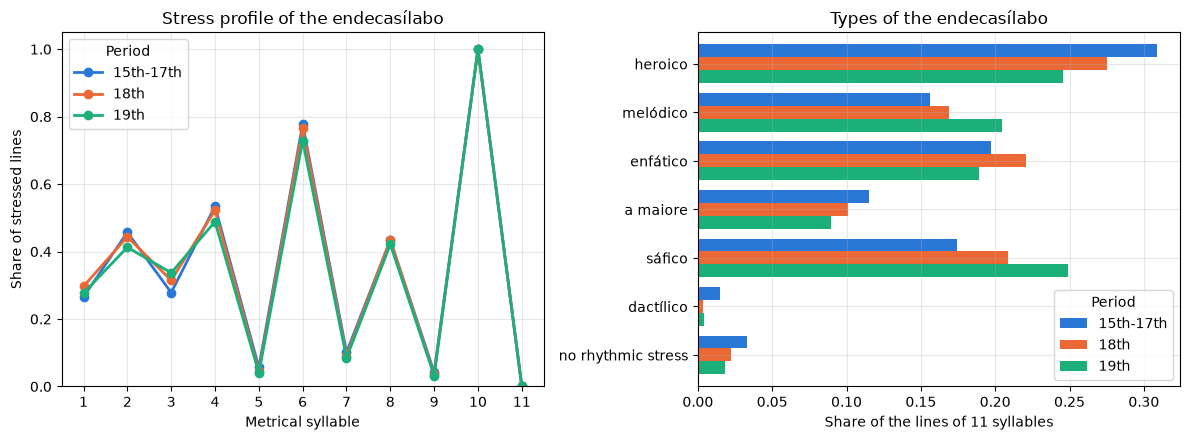

In [14]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5))
for period, color in zip(PERIODS, COLORS, strict=True):
    left.plot(profiles.index, profiles[period], marker="o", color=color, lw=2, label=period)
left.set(
    title="Stress profile of the endecasílabo",
    xlabel="Metrical syllable",
    ylabel="Share of stressed lines",
    xticks=range(1, 12),
    ylim=(0, 1.05),
)
type_shares.T.plot.barh(ax=right, color=COLORS, width=0.8)
right.invert_yaxis()
right.set(
    title="Types of the endecasílabo", xlabel="Share of the lines of 11 syllables", ylabel=""
)
for ax in (left, right):
    ax.grid(alpha=0.3)
    ax.legend(title="Period")
fig.tight_layout()
plt.show()

The stress profile is almost the same in the three periods: the 10th syllable is always stressed, the 6th in 0.73-0.78 of the lines, the 4th in about half and the 2nd in 0.41-0.46, while the 5th, 7th and 9th are nearly never stressed (0.03-0.10), so the second half of the line alternates strictly. The types move more. The heroico (2-6-10) falls from 30.9% of the lines to 27.5% and 24.6%, while the sáfico (4-8-10) rises from 17.4% to 20.8% and 24.9% and the melódico (3-6-10) from 15.6% to 20.4%, so that in the 19th century the sáfico is as common as the heroico. The dactílico (4-7-10) is rare, 1.5% in the 15th-17th century and below 0.5% later, and the lines with none of the rhythmic stresses fall from 3.3% to 1.8%.

## Rhyme

A line [rhymes](https://sergeyshk.github.io/esTS/stats/verse_stats/#rhyme) with one of the four lines before it in full (consonante) when its sounds from the last stressed vowel are the same, or by assonance (asonante) when only the vowels are; the scheme gives upper-case letters to the lines of arte mayor and a hyphen to an unrhymed line, and the form `soneto` asks for 14 lines of arte mayor in full rhyme with the quatrains ABBA or ABAB and the tercets on rhymes of their own. The table gives the shares of the lines by the kind of their rhyme and the share of the poems that `VerseStats` names `soneto`.

In [15]:
rhymes = pd.DataFrame([verse.c_rhymes for verse in verses]).fillna(0)
rhymes["unrhymed"] = [verse.n_lines for verse in verses] - rhymes.sum(axis=1)
rhyme_lines = rhymes.groupby(periods).sum()
kinds = rhyme_lines.div(rhyme_lines.sum(axis=1), axis=0)
kinds["sonnets with asonante"] = (rhymes.asonante > 0).groupby(periods).sum()
kinds["form soneto"] = (
    pd.Series([verse.form == "soneto" for verse in verses]).groupby(periods).mean()
)
kinds.loc[PERIODS].round(3)

,consonante,asonante,unrhymed,sonnets with asonante,form soneto
period,,,,,
15th-17th,0.987,0.000,0.013,0,0.843
18th,0.995,0.000,0.005,0,0.931
19th,0.984,0.004,0.012,18,0.873


The Spanish sonnet rhymes in full: 98.4-99.5% of the lines are consonantes, 0.5-1.3% stay unrhymed, and the assonance appears only in the 19th century, in 0.4% of its lines and 18 sonnets. `VerseStats` names 84.3%, 93.1% and 87.3% of the poems a `soneto`; the others break one of the conditions of the form - a line without a rhyme, an assonance, tercets on the rhymes of the quatrains, or a number of lines other than 14.

The schemes of the quatrains and of the tercets are counted on the sonnets of two quatrains and two tercets; the letters of the tercets are renamed from C in the order of their appearance, so that `CDC DCD` is the same pattern whatever the quatrains are.

In [16]:
def relabel(scheme, first="A"):
    letters = {}
    renamed = []
    for label in scheme:
        if label.isalpha():
            label = letters.setdefault(label.upper(), chr(ord(first) + len(letters)))
        renamed.append(label)
    return "".join(renamed)


regular = [tuple(map(len, verse.stanzas)) == (4, 4, 3, 3) for verse in verses]
schemes = pd.DataFrame(
    {
        "period": periods,
        "quatrains": [" ".join(verse.rhyme_schemes[:2]) for verse in verses],
        "tercets": [relabel(" ".join(verse.rhyme_schemes[2:]), "C") for verse in verses],
    }
)[pd.Series(regular) & periods.isin(PERIODS)]
print(f"Sonnets of two quatrains and two tercets: {len(schemes)}")


def scheme_shares(column, n_rows):
    table = pd.crosstab(schemes[column], schemes.period, normalize="columns")
    table["all"] = schemes[column].value_counts(normalize=True)
    return table.sort_values("all", ascending=False, kind="stable").head(n_rows).round(3)


scheme_shares("quatrains", 4)

Sonnets of two quatrains and two tercets: 4197


period,15th-17th,18th,19th,all
quatrains,,,,
ABBA ABBA,0.914,0.972,0.816,0.853
ABAB ABAB,0.021,0.006,0.051,0.040
ABAB CDCD,0.000,0.000,0.032,0.021
ABBA CDDC,0.001,0.000,0.011,0.007


In [17]:
scheme_shares("tercets", 6)

period,15th-17th,18th,19th,all
tercets,,,,
CDC DCD,0.276,0.548,0.426,0.397
CDE CDE,0.589,0.389,0.178,0.298
CCD EED,0.000,0.000,0.165,0.111
CDC EDE,0.000,0.006,0.079,0.053
CDC DEE,0.001,0.003,0.042,0.029
CDE DCE,0.035,0.006,0.006,0.013


The quatrains are ABBA ABBA in 91.4%, 97.2% and 81.6% of the sonnets; the alternating ABAB ABAB, already 2.1% in the 15th-17th century and 0.6% in the 18th, grows to 5.1% in the 19th, which also brings in quatrains on four rhymes, ABAB CDCD (3.2%) and ABBA CDDC (1.1%), almost absent before. The tercets change more. The 15th-17th century prefers three rhymes, CDE CDE (58.9%), to two, CDC DCD (27.6%); the 18th century turns this round (54.8% CDC DCD against 38.9%), and the 19th adds schemes almost absent before: CCD EED (16.5%), the tercets of the French sonnet, CDC EDE (7.9%) and CDC DEE (4.2%).

### The rhyme against DISCO

The labels of the two annotations are compared as pairs of lines that rhyme together, which makes them independent of the letters; the sonnets with a line that DISCO leaves without a label are left out.

In [18]:
def rhyme_pairs(labels):
    return {
        (first, second)
        for first, second in combinations(range(len(labels)), 2)
        if labels[first] != "-" and labels[first].upper() == labels[second].upper()
    }


labelled = [i for i, record in enumerate(records) if all(record["rhyme"])]
ours = {i: rhyme_pairs("".join(verses[i].rhyme_schemes)) for i in labelled}
theirs = {i: rhyme_pairs(records[i]["rhyme"]) for i in labelled}
found = sum(len(ours[i] & theirs[i]) for i in labelled)
same_scheme = pd.Series({i: ours[i] == theirs[i] for i in labelled})
print(f"Sonnets compared: {len(labelled)}, with the same scheme: {same_scheme.mean():.1%}")
print(f"Pairs of esTS that DISCO has: {found / sum(map(len, ours.values())):.1%}")
print(f"Pairs of DISCO that esTS finds: {found / sum(map(len, theirs.values())):.1%}")
same_scheme.groupby(periods).mean().loc[PERIODS].round(3)

Sonnets compared: 4233, with the same scheme: 93.9%


Pairs of esTS that DISCO has: 99.3%
Pairs of DISCO that esTS finds: 97.9%


period
15th-17th    0.921
18th         0.947
19th         0.945
dtype: float64

In [19]:
def last_word(line):
    return re.findall(r"[^\W\d_]+", line)[-1].lower()


missed = pd.DataFrame(
    [
        (periods[i], last_word(verses[i].lines[first]), last_word(verses[i].lines[second]))
        for i in labelled
        for first, second in sorted(theirs[i] - ours[i])
    ],
    columns=["period", "line", "rhymes in DISCO with"],
)
missed.drop_duplicates().groupby("period").head(4).reset_index(drop=True)

,period,line,rhymes in DISCO with
0,15th-17th,cuidados,quedado
1,15th-17th,hechos,cielos
2,15th-17th,rompa,interrumpa
3,15th-17th,trompa,interrumpa
4,18th,autoriza,prisa
5,18th,prisa,ceniza
6,18th,gentileza,pavesa
7,18th,belleza,pavesa
8,19th,concentra,inquieta
9,19th,concentra,poeta


esTS and DISCO make the same pairs of rhyming lines in 93.9% of the 4,233 sonnets compared, from 92.1% in the 15th-17th century to 94.5-94.7% later. 99.3% of the pairs esTS finds are in DISCO, and it finds 97.9% of the pairs of DISCO, so esTS is the stricter of the two. The pairs it misses are loose rhymes: a plural with a singular (*cuidados* - *quedado*), an assonance inside a sonnet in full rhyme (*hechos* - *cielos*, *concentra* - *poeta*), different vowels (*rompa* - *interrumpa*), and rhymes that are full only with seseo (*prisa* - *ceniza*, *gentileza* - *pavesa*, *heces* - *cipreses*), which the last section takes up.

## Sound and seseo

[`PhonStats`](https://sergeyshk.github.io/esTS/stats/phon_stats/) transcribes the words into sounds and counts the classes of sounds - vowels, sonorants (m, n, ñ, l, r), voiced and voiceless obstruents - and the [indices of alliteration and assonance](https://sergeyshk.github.io/esTS/stats/phon_stats_funcs/#calc_alliteration): the observed number of windows of three neighbouring words that repeat a consonant (a vowel) against the number expected if the words stood in random order. The table gives the means over the sonnets by period and, for the 19th century, by the region of the poet.

In [20]:
PHON_COLUMNS = [
    "p_vowels", "p_sonorants", "p_voiced", "p_voiceless", "hardness", "alliteration", "assonance",
]  # fmt: skip
phon_stats = [PhonStats(record["text"]) for record in records]
phon = pd.DataFrame([stats.get_stats() for stats in phon_stats])[PHON_COLUMNS]
groups = {period: periods == period for period in PERIODS}
groups |= {
    f"19th, {region}": (periods == "19th") & (sonnets.region == region)
    for region in ("Spain", "America")
}
phon_table = pd.DataFrame({name: phon[mask].mean() for name, mask in groups.items()}).T
print("Standard deviation over the sonnets:", phon.std().round(3).to_dict())
phon_table.assign(sonnets=[mask.sum() for mask in groups.values()]).round(3)

Standard deviation over the sonnets: {'p_vowels': 0.014, 'p_sonorants': 0.019, 'p_voiced': 0.016, 'p_voiceless': 0.024, 'hardness': 0.042, 'alliteration': 0.078, 'assonance': 0.044}


,p_vowels,p_sonorants,p_voiced,p_voiceless,hardness,alliteration,assonance,sonnets
15th-17th,0.470,0.222,0.095,0.213,0.309,0.929,0.987,1088
18th,0.472,0.225,0.095,0.208,0.300,0.924,0.980,321
19th,0.469,0.231,0.093,0.207,0.297,0.921,0.984,2845
"19th, Spain",0.471,0.230,0.094,0.206,0.295,0.921,0.985,1106
"19th, America",0.468,0.231,0.093,0.208,0.298,0.921,0.984,1709


The sound of the sonnet hardly changes. Between the periods, and between Spain and America in the 19th century, the means differ by 0.014 at most: the vowels make 0.468-0.472 of the sounds, the voiceless obstruents 0.206-0.213. The only drift is a slight softening, the sonorants rising from 0.222 to 0.231 and the hardness falling from 0.309 to 0.297, small against the spread of single sonnets (standard deviation 0.042 for the hardness). The indices are alike in all the groups too, 0.921-0.929 for the alliteration and 0.980-0.987 for the assonance; what they mean is read against the level that chance gives, checked below.

### A baseline for the indices

The expected number of the index is the one of the words of the text in random order, so the words of a sonnet shuffled should give about 1. The check is direct: the words of every sonnet are shuffled (one permutation with seed 0) and the indices are computed again with `calc_alliteration` and `calc_assonance`, on the same words in random order.

In [21]:
rng = np.random.default_rng(0)
shuffled = [rng.permutation(stats.words).tolist() for stats in phon_stats]
baseline = pd.DataFrame(
    {
        "alliteration": [calc_alliteration(words) for words in shuffled],
        "assonance": [calc_assonance(words) for words in shuffled],
    }
)
indices = phon[["alliteration", "assonance"]]
print(f"Words per sonnet: {np.mean([len(stats.words) for stats in phon_stats]):.0f} on average")
pd.DataFrame(
    {
        "mean, sonnets": indices.mean(),
        "mean, shuffled": baseline.mean(),
        "above 1, sonnets": (indices > 1).mean(),
        "above 1, shuffled": (baseline > 1).mean(),
        "sonnets below their shuffle": (indices < baseline).mean(),
    }
).round(3)

Words per sonnet: 93 on average


,"mean, sonnets","mean, shuffled","above 1, sonnets","above 1, shuffled",sonnets below their shuffle
alliteration,0.923,0.997,0.165,0.486,0.734
assonance,0.985,0.999,0.356,0.492,0.573


Shuffled, the words of the sonnets give mean indices of 0.997 for the alliteration and 0.999 for the assonance, and about half of the shuffled sonnets exceed 1 (48.6% and 49.2%): even for texts this short (93 words on average) 1 is the level of chance. The real sonnets fall below it: their mean alliteration index is 0.923, 16.5% of them exceed 1, and 73.4% have a lower index than their own words in random order. A sonnet thus repeats a consonant in neighbouring words less often than chance would. The assonance is nearer chance, 0.985 against 0.999, with 57.3% of the sonnets below their shuffle.

In [22]:
top = phon.alliteration.nlargest(5).index
pd.DataFrame(
    {
        "author": sonnets.author[top],
        "period": periods[top],
        "first line": [records[i]["text"].split("\n")[0] for i in top],
        "alliteration": phon.alliteration[top],
        "assonance": phon.assonance[top],
    }
).round(2)

,author,period,first line,alliteration,assonance
3276,León María Carbonero y Sol,19th,"¡Oh vana, oh loca, oh atrevida vida",1.30,1.08
960,Juan López de Úbeda,15th-17th,"Dulcísimo Jesús, mi amor festina,",1.28,1.07
3670,Julio Flores Roa,19th,Te di el perdón y te alargué mi mano;,1.23,0.94
30,Fray Luis de León,15th-17th,Mucho a la Majestad sagrada agrada,1.22,1.03
574,Pedro Calderón Riaño,15th-17th,"La que ves en piedad, en llama, en vuelo",1.21,0.98


The sonnets with the highest alliteration index, 1.21-1.30, well above the shuffled level, are the ones built on echoes of sound, such as *atrevida vida* in the first line of León María Carbonero y Sol and *sagrada agrada* in Fray Luis de León; so the index finds the poems where alliteration is a device, while on average the sonnets stay below chance.

### Seseo in the rhyme

Both classes of esTS read Spanish by the standard of Spain, with distinción: `c` before `e` and `i` and `z` sound θ, apart from `s`. In America and in Andalusia they sound `s` (seseo), so a poet may rhyme *prisa* with *ceniza*. `PhonStats` counts θ and s both as voiceless obstruents, so its shares of the classes do not depend on it; the rhyme does, and `VerseStats(..., seseo=True)` reads it with seseo. The sonnets of Spain and America are scanned again with seseo and compared with the default reading and with DISCO; the table gives percentages.

In [23]:
compared = sonnets.index[sonnets.region.isin(["Spain", "America"])].tolist()
with_seseo = {i: VerseStats(records[i]["text"], seseo=True) for i in compared}
check = pd.DataFrame(
    {
        "region": sonnets.region[compared],
        "scheme changes": [
            with_seseo[i].rhyme_schemes != verses[i].rhyme_schemes for i in compared
        ],
        "rhymed lines": [verses[i].p_rhymed for i in compared],
        "rhymed lines, seseo": [with_seseo[i].p_rhymed for i in compared],
        "form soneto": [verses[i].form == "soneto" for i in compared],
        "form soneto, seseo": [with_seseo[i].form == "soneto" for i in compared],
    }
)
print("Sonnets:", check.region.value_counts().to_dict())
by_region = check.groupby("region").mean().T
default_pairs = {i: rhyme_pairs("".join(verses[i].rhyme_schemes)) for i in compared}
seseo_pairs = {i: rhyme_pairs("".join(with_seseo[i].rhyme_schemes)) for i in compared}
compared_labelled = [i for i in compared if i in theirs]
for suffix, pairs in (("", default_pairs), (", seseo", seseo_pairs)):
    agreement = (
        pd.DataFrame(
            {
                "region": sonnets.region[i],
                "found": len(pairs[i] & theirs[i]),
                "ours": len(pairs[i]),
                "theirs": len(theirs[i]),
            }
            for i in compared_labelled
        )
        .groupby("region")
        .sum()
    )
    by_region.loc[f"pairs of esTS in DISCO{suffix}"] = agreement.found / agreement.ours
    by_region.loc[f"pairs of DISCO found{suffix}"] = agreement.found / agreement.theirs
(by_region[["Spain", "America"]] * 100).round(1)

Sonnets: {'Spain': 2388, 'America': 1758}


region,Spain,America
scheme changes,0.4,2.3
rhymed lines,98.9,98.8
"rhymed lines, seseo",98.9,99.0
form soneto,88.5,85.2
"form soneto, seseo",88.7,87.1
pairs of esTS in DISCO,99.1,99.6
pairs of DISCO found,97.7,98.3
"pairs of esTS in DISCO, seseo",99.1,99.4
"pairs of DISCO found, seseo",97.7,98.5


In [24]:
new_rhymes = [
    f"{last_word(verses[i].lines[first])} - {last_word(verses[i].lines[second])}"
    for i in compared
    if sonnets.region[i] == "America"
    for first, second in sorted(seseo_pairs[i] - default_pairs[i])
]
lost = sum(
    len(default_pairs[i] - seseo_pairs[i]) for i in compared if sonnets.region[i] == "America"
)
print(
    f"Pairs of the American sonnets that rhyme only with seseo: {len(new_rhymes)}, pairs lost: {lost}"
)
print(", ".join(list(dict.fromkeys(new_rhymes))[:14]))

Pairs of the American sonnets that rhyme only with seseo: 91, pairs lost: 0
aviso - quebradizo, paraíso - quebradizo, quebradizo - quiso, espinosa - goza, rosa - goza, goza - artificiosa, autoriza - prisa, prisa - ceniza, gentileza - pavesa, belleza - pavesa, enfurece - cese, comparece - cese, heces - cipreses, sonrisa - martiriza


Seseo changes the rhyme scheme of 2.3% of the American sonnets and of 0.4% of the Spanish ones. In the American sonnets it adds 91 pairs of rhyming lines and removes none - *goza* - *rosa*, *prisa* - *ceniza*, *sonrisa* - *martiriza*, *heces* - *cipreses* - so their share of rhymed lines rises from 98.8% to 99.0% and the share of the poems named `soneto` from 85.2% to 87.1%. Against DISCO the result is mixed: with seseo esTS finds more of its pairs (98.3% to 98.5%), but fewer of the pairs it finds are in DISCO (99.6% to 99.4%), so RhymeTagger takes some rhymes of seseo, *prisa* - *ceniza* among them, and not others.

## Summary

- **Meter.** The sonnet is an endecasílabo in 98.6-99.7% of the sonnets up to the 18th century; the 19th century adds the alejandrino (11.0%) and other meters. `VerseStats` agrees with the annotation of DISCO on the meter of 98.9% of the sonnets and on the length of 97.0% of the lines; they part most on the alejandrino, which esTS reads as 7 + 7 and DISCO counts 13 in 14.3% of its lines.
- **Rhythm.** The stress profile of the endecasílabo is stable from the 15th-17th century to the 19th, while its types shift from the heroico (30.9% to 24.6%) to the sáfico (17.4% to 24.9%) and the melódico.
- **Rhyme.** Almost every line rhymes in full; the quatrains stay ABBA ABBA, while the tercets move from CDE CDE in the 15th-17th century to CDC DCD in the 18th, and the 19th adds new schemes, CCD EED first (16.5%). esTS and DISCO make the same rhyme pairs in 93.9% of the sonnets, esTS being the stricter.
- **Sound.** The phonostatistics barely differ between periods and between Spain and America. The alliteration index of the sonnets is below 1, the level of their words in random order (0.923 against 0.997 for the shuffled words, 73.4% of them below their own shuffle): the sonnets repeat a consonant in neighbouring words less often than chance, and only single poems built on echoes of sound reach 1.21-1.30.
- **Seseo.** Reading the American sonnets with seseo adds 91 rhyme pairs and brings their share of poems named `soneto` nearer to the Spanish one (87.1% against 88.5%); the agreement with DISCO does not settle which reading is right.